In [1]:
# 24.08.2026, wieczor (kontynuacja) - Maciek: "zrob co w twojej mocy, aby
# piaty peak sie pojawil tak samo jak w artykule". Dwa brakujace elementy
# zidentyfikowane wczesniej w rozmowie, oba wprost z artykulu, dotad
# nieuzywane w zadnym naszym skanie:
#
# 1. Lag Δt=15 dni - sekcja 4 explicite zachowuje "the same values which
#    gave the results presented in Fig. 2", a Fig. 2 uzywa Δt=15d (nie
#    Δt=0 jak nasza dotychczasowa konwencja "no lag" z instrukcji Homoli -
#    ta instrukcja dotyczyla tylko SZEROKIEGO, nieoptymalizowanego skanu).
# 2. Precyzja t0 - podpis Fig. 2: "All the significance curves were
#    obtained after fine tuning of the parameter t0 performed by applying
#    20 small shifts in time between 0 and 5 days." Krok 5 dni / 20 = 6h -
#    dokladnie natywna rozdzielczosc danych CR Moskwy. Nasze dotychczasowe
#    skany cykl-do-cyklu uzywaly kroku 24h (zbyt grubego) - test w rozmowie
#    (bezposrednia ewaluacja W DOKLADNEJ dacie z artykulu, dt=15) pokazal,
#    ze PPDF jest bardzo wrazliwe na dokladna faze binu (zgodnie z
#    ostrzezeniem samego artykulu: "sensitivity to small shifts of the
#    data bins in time, of the lengths less than the individual bin size").
#
# PLAN: skan lokalny (nie caly zakres 1965-2025 - to bylby duzo kosztowniejszy
# nawrot do pelnego skanu) w oknie 2004-01-01..2013-01-01 (era juz
# wielokrotnie flagowana w tym tygodniu jako "klaster graniczny 1996/2008"),
# krok 6h (=natywna rozdzielczosc Moskwy = dokladnie "20 male przesuniecia w
# 5 dniach" z podpisu artykulu), P=3350, d=5, m=4.0, Δt=15 - PIERWSZY nasz
# skan z prawidlowym lagiem I odpowiednia rozdzielczoscia jednoczesnie.
#
# UWAGA O KOSZCIE: to REALNY, nowy skan (13153 kandydatow x pelne okno
# 3350-dniowe), nie tania reanaliza istniejacych plikow - ale ograniczony do
# 9 lat (nie calej historii 1965-2025) i tylko Moskwy, wiec rzedu kilku-
# kilkunastu minut z run_t0_scan_parallel (rownolegle), NIE godzin.
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

sys.path.insert(0, "..")
from mc_parallel import run_t0_scan_parallel

RESULTS_DIR = "../results"
MOSC_PATH = "../data/mosc_data.csv"
USGS_EXTENDED_PATH = "../data/usgs_data/usgs_m4_1965_2025.csv"

ARTICLE_T0 = pd.Timestamp("2009-02-23 07:37:12")
ARTICLE_PPDF = 8.1e-9
P_DAYS = 3350
D_DAYS = 5
M_THRESHOLD = 4.0
DT_DAYS = 15  # przepis artykulu (Fig.2/sekcja 4), NIE nasza zwykla konwencja dt=0


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_earthquakes_extended(min_mag=4.0):
    df = pd.read_csv(USGS_EXTENDED_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


mosc = load_mosc()
eq = load_earthquakes_extended(min_mag=M_THRESHOLD)
print(f"mosc: {len(mosc)} pomiarow, {mosc.index.min()} .. {mosc.index.max()}")
print(f"EQ (rozszerzony katalog, M>={M_THRESHOLD}): {len(eq)} zdarzen")

mosc: 91824 pomiarow, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00
EQ (rozszerzony katalog, M>=4.0): 507919 zdarzen


In [2]:
# Skan lokalny, krok 6h, 2004-01-01..2013-01-01 (9 lat = 13153 kandydatow),
# P=3350, d=5, m=4.0, dt=15. Przyciecie cr/eq do minimalnego potrzebnego
# zakresu PRZED wywolaniem (jak w 20260819a.ipynb - optymalizacja
# wydajnosci, run_t0_scan_parallel robi pd.cut na calym cr.index przy
# kazdym wywolaniu). Zapis atomowy (jak wszystkie inne skany w tym repo) -
# bezpiecznie przerywalny/wznawialny. Szacowany czas: rzedu kilku-
# kilkunastu minut (rownolegle; jednowatkowa wersja tego samego skanu w
# rozmowie zajela ~7.5 min).
t0_candidates = pd.date_range("2004-01-01", "2013-01-01", freq="6h")
print(f"Liczba kandydatow t0: {len(t0_candidates)}")

scan_end = t0_candidates.max() + pd.Timedelta(days=P_DAYS) + pd.Timedelta(days=DT_DAYS)
mosc_clipped = mosc[(mosc.index >= t0_candidates.min()) & (mosc.index <= scan_end)]
eq_clipped = eq[(eq.index >= t0_candidates.min()) & (eq.index <= scan_end)]
print(f"mosc_clipped: {len(mosc_clipped)}, eq_clipped: {len(eq_clipped)}")

finetune_scan = run_t0_scan_parallel(
    mosc_clipped, eq_clipped, t0_candidates,
    P_days=P_DAYS, d_days=D_DAYS, m=M_THRESHOLD, dt_days=DT_DAYS,
    stat_fn=cosmoseismic_stat,
    save_path=f"{RESULTS_DIR}/finetune_mosc_P3350_d5_dt15_scan.csv",
)
print(f"Gotowe: {len(finetune_scan)} wierszy")

Liczba kandydatow t0: 13153
mosc_clipped: 26257, eq_clipped: 259594
Gotowe: 13153 wierszy


In [3]:
# Porownanie z artykulem: 10 najsilniejszych znalezionych punktow vs
# zgloszony przez artykul t0=23 lut 2009 07:37:12, PPDF=8.1e-9.
scan = pd.read_csv(f"{RESULTS_DIR}/finetune_mosc_P3350_d5_dt15_scan.csv", parse_dates=["t0"]).dropna(subset=["PPDF"])
scan = scan[scan["PPDF"] > 0]
scan["days_from_article_t0"] = (scan["t0"] - ARTICLE_T0).dt.days
scan["log10_PPDF"] = np.log10(scan["PPDF"])

top10 = scan.nsmallest(10, "PPDF")
pd.set_option("display.width", 160)
print("10 najsilniejszych punktow naszego skanu (dt=15, krok 6h):")
print(top10.to_string(index=False))

print(f"\nArtykul: t0={ARTICLE_T0}, PPDF={ARTICLE_PPDF:.2e} (log10={np.log10(ARTICLE_PPDF):.2f})")
nearest_to_article = scan.iloc[scan["days_from_article_t0"].abs().idxmin()]
print(f"\nNajblizszy naszemu skanowi wzgledem DATY artykulu: t0={nearest_to_article['t0']}, "
      f"PPDF={nearest_to_article['PPDF']:.2e} (log10={nearest_to_article['log10_PPDF']:.2f}), "
      f"{nearest_to_article['days_from_article_t0']:.0f} dni od daty artykulu")

global_best = scan.loc[scan["PPDF"].idxmin()]
print(f"\nGlobalne minimum w oknie 2004-2013: t0={global_best['t0']}, PPDF={global_best['PPDF']:.2e} "
      f"(log10={global_best['log10_PPDF']:.2f}), {global_best['days_from_article_t0']:.0f} dni od daty artykulu")

10 najsilniejszych punktow naszego skanu (dt=15, krok 6h):
  N  N_valid  Np  Nm         PPDF         PCDF    sigma         t0  days_from_article_t0  log10_PPDF
670      667 408 259 1.628387e-09 4.363111e-09 5.753795 2008-09-27                  -150   -8.788242
670      667 407 260 2.555314e-09 6.918425e-09 5.675396 2008-10-02                  -145   -8.592556
670      667 407 260 2.555314e-09 6.918425e-09 5.675396 2008-10-22                  -125   -8.592556
670      667 407 260 2.555314e-09 6.918425e-09 5.675396 2009-02-04                   -20   -8.592556
670      667 407 260 2.555314e-09 6.918425e-09 5.675396 2009-02-09                   -15   -8.592556
670      667 406 261 3.984724e-09 1.090315e-08 5.597024 2008-07-24                  -215   -8.399602
670      667 406 261 3.984724e-09 1.090315e-08 5.597024 2008-09-02                  -175   -8.399602
670      667 406 261 3.984724e-09 1.090315e-08 5.597024 2008-09-07                  -170   -8.399602
670      667 406 261 3.984724e-0

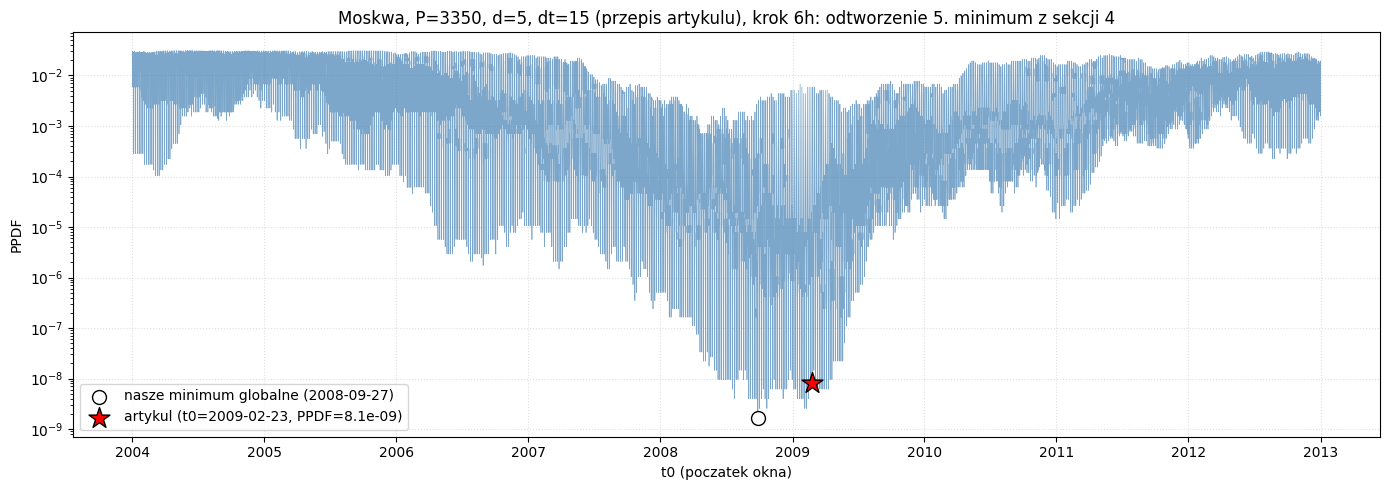

In [4]:
# Wykres: krajobraz PPDF w oknie 2004-2013 (krok 6h, dt=15) - nasze
# znalezione minimum + punkt z artykulu, zeby zobaczyc jak blisko siebie
# leza na tle calego lokalnego "krajobrazu".
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(scan["t0"], scan["PPDF"], color="steelblue", lw=0.5, alpha=0.7)
ax.scatter([global_best["t0"]], [global_best["PPDF"]], color="white", edgecolor="black",
           s=100, zorder=5, label=f"nasze minimum globalne ({global_best['t0'].date()})")
ax.scatter([ARTICLE_T0], [ARTICLE_PPDF], color="red", marker="*", s=250,
           edgecolor="black", zorder=6, label=f"artykul (t0={ARTICLE_T0.date()}, PPDF={ARTICLE_PPDF:.1e})")
ax.set_yscale("log")
ax.set_xlabel("t0 (poczatek okna)")
ax.set_ylabel("PPDF")
ax.set_title("Moskwa, P=3350, d=5, dt=15 (przepis artykulu), krok 6h: odtworzenie 5. minimum z sekcji 4")
ax.legend()
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/finetune_mosc_vs_article_5th_minimum.png", dpi=130)
plt.show()